# Limestone Data Challenge

In [76]:
import platform
import typing as t

import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import xgboost as xgb
import torch

import matplotlib
import matplotlib.pyplot as plt
import plotly

from scipy.optimize import nnls
from scipy.signal import periodogram

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer


## Notebook roadmap

1. Data quality and missingness diagnostics
2. Price-level structure and trend visuals
3. PCA on row-demeaned residuals + loadings
4. Residual variance and residual-noise diagnostics
5. NNLS explainability on residuals, levels, and first differences
6. Feature fusion: first-pass per-column index likelihood table


In [77]:

def submit_answer_1(index_formulas: pd.DataFrame) -> None:
    from pandas.api.types import is_float_dtype

    assert sorted(index_formulas.columns) == sorted(["index_col", "constituent_col", "coef"])
    assert is_float_dtype(index_formulas["coef"].dtype)
    assert np.all(index_formulas["coef"] >= 0)

    COLUMNS = [f"col_{i:02d}" for i in range(53)]
    for (ic, cc) in zip(
        index_formulas["index_col"],
        index_formulas["constituent_col"],
    ):
        assert isinstance(ic, str)
        assert isinstance(cc, str)
        assert ic != cc
        assert ic in COLUMNS
        assert cc in COLUMNS

    index_formulas.to_csv(
        "modelling_prices.submission.1.csv",
        index=False
    )


### Workspace

In [78]:
DF = pd.read_csv("limestone_data_challenge_2026.data.csv")
DF = DF.set_index(keys="time")

DF.head()

,col_00,col_01,col_02,col_03,col_04,col_05,col_06,col_07,col_08,col_09,...,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50,col_51,col_52
time,,,,,,,,,,,,,,,,,,,,,
0,120.138568,111.692124,110.158297,NaN,120.151012,120.181427,NaN,119.740662,NaN,119.977510,...,119.940305,NaN,132.272741,121.768336,NaN,NaN,109.859416,117.808491,119.703005,129.671178
1,121.096957,116.345227,111.709693,NaN,121.626153,121.726396,116.393623,118.050353,123.850491,119.548152,...,123.738967,NaN,NaN,121.896705,NaN,122.699758,110.518188,NaN,NaN,NaN
2,121.377886,NaN,122.153833,118.841414,120.956851,115.415875,124.882967,114.971317,NaN,124.618823,...,125.648662,112.937734,119.998389,116.053638,NaN,118.439899,111.880012,119.799799,120.144533,129.001756
3,NaN,126.247280,127.163454,NaN,119.960063,121.063165,NaN,112.059290,115.168068,NaN,...,NaN,117.205598,115.513093,NaN,124.213788,NaN,NaN,121.112225,122.093434,NaN
4,NaN,120.515769,NaN,116.856146,120.671093,118.978446,NaN,113.936539,116.821607,126.453764,...,127.848139,119.035464,117.431307,NaN,123.244609,120.140786,NaN,122.716514,NaN,126.796467


In [ ]:
# Shared helpers used across later sections

def nnls_leave_one_out_r2(Z: np.ndarray, col_names) -> pd.Series:
    """Each column j: predict y = Z[:,j] from all other columns with non-negative coefficients."""
    _, n = Z.shape
    out = {}
    for j in range(n):
        y = Z[:, j].astype(np.float64, copy=False)
        X = np.delete(Z, j, axis=1)
        ss_tot = np.sum((y - y.mean()) ** 2)
        if ss_tot < 1e-18:
            out[col_names[j]] = np.nan
            continue
        beta, _ = nnls(X, y)
        pred = X @ beta
        ss_res = np.sum((y - pred) ** 2)
        out[col_names[j]] = float(1.0 - ss_res / ss_tot)
    return pd.Series(out, name="r2_nnls")


def periodogram_flatness(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 64:
        return np.nan
    _, pxx = periodogram(x, detrend="constant")
    pxx = np.maximum(pxx, 1e-20)
    return float(np.exp(np.mean(np.log(pxx))) / np.mean(pxx))


def lag1_acf_calendar(series: pd.Series) -> float:
    """Pearson correlation between r_t and r_{t-1} using rows where both exist."""
    prev = series.shift(1)
    m = series.notna() & prev.notna()
    if m.sum() < 5:
        return np.nan
    x = series[m].to_numpy(dtype=float)
    y = prev[m].to_numpy(dtype=float)
    return float(np.corrcoef(x, y)[0, 1])


## Understanding the distribution of Nans:

It would be prudcent to understand if only prices hae NaN values or indexes have NaN values too, we should look at the ditribution of NaNs amongst columns to first of all understand the data

In [79]:
# total NaNs in the data
total_nans = DF.isna().sum().sum()
print(f"Total NaN ={total_nans}")

#30-60% NaNs

#Nans per column of data 
columns_all_defined = DF.isna().sum().eq(0).sum()
print(columns_all_defined)

Total NaN =94470
0


So quite clearly all columns have NaN values including both prices and index data even though the question didn't explictly state this, there was ambiguity about what smudged "prices" was referring to be it is quite claer now that his was referring to both index prices and the actual prices of the columns.

### Understanding how NaNs are distributed in columns 

<Axes: >

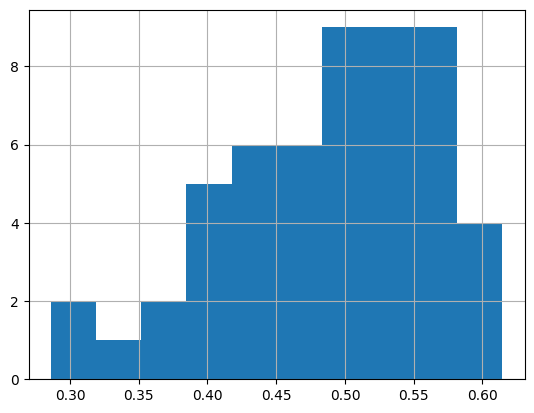

In [80]:
percent_undefined = DF.isna().sum()/len(DF.index)
percent_undefined.hist()

Quite clearly the data is extremely sparse with many columns having a range oof 0.30-0.60 of their data missing 

### Is data missing in contiguous blocks within columns or is it randomly missing? 

This has secondary impacts for inference when we build our trading strategies and may also inform some other aspects of our analysis. 

=== Whole dataset ===
Share of (row, column) cells missing: 0.4883
NAs per row (how many series missing on the same day): min=10, median=26, max=43


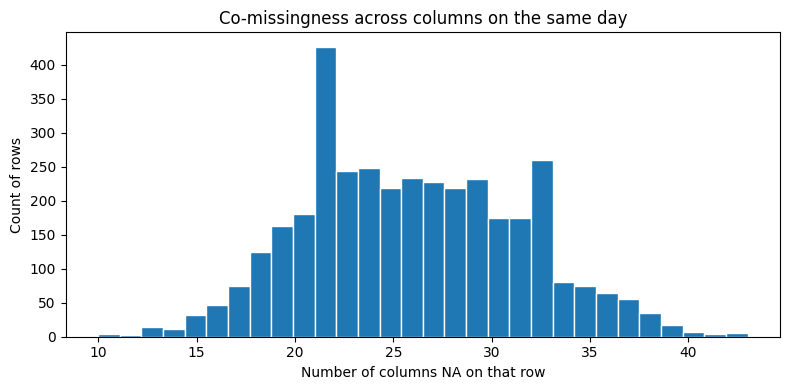


Pairwise correlation of missingness indicators (off-diagonal): median=0.020, mean=0.026
(Higher values → missingness more aligned in time across series.)


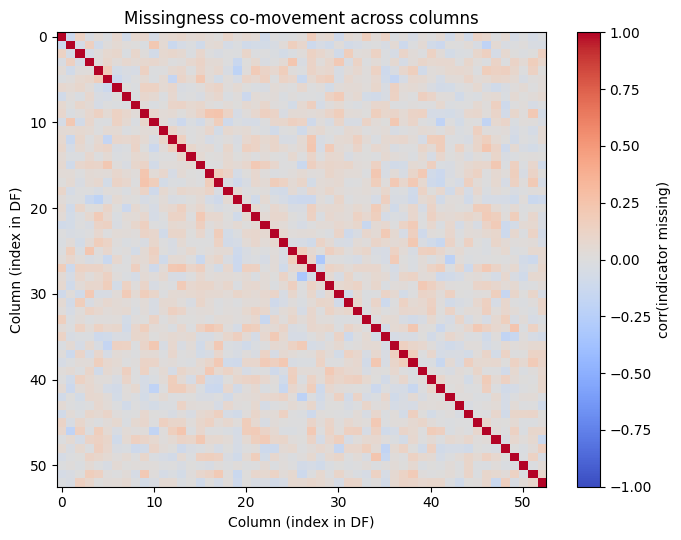


=== Per-column contiguous NaN runs (time-ordered rows) ===
runs_vs_iid = (# observed NA runs) / (expected # runs if each row were NA independently with that column's marginal rate p).
  < 1  → longer blocks / fewer runs than iid (gaps clump in time)
  ~ 1  → similar fragmentation to iid at random
  > 1  → shorter runs / more alternation than iid

Largest mean contiguous NA length (rows ≈ days):
        n_na  n_runs  mean_run  median_run  max_run  runs_vs_iid
column                                                          
col_23  2073     318  6.518868         1.0      331     0.354922
col_51  2242     400  5.605000         1.0      322     0.462301
col_22  2187     411  5.321168         1.0      399     0.468666
col_48  2114     401  5.271820         1.0      404     0.450586
col_05  2108     401  5.256858         1.0      363     0.450111
col_25  2222     430  5.167442         1.0      219     0.494429
col_35  2181     437  4.990847         1.0      266     0.497646
col_03  2120    

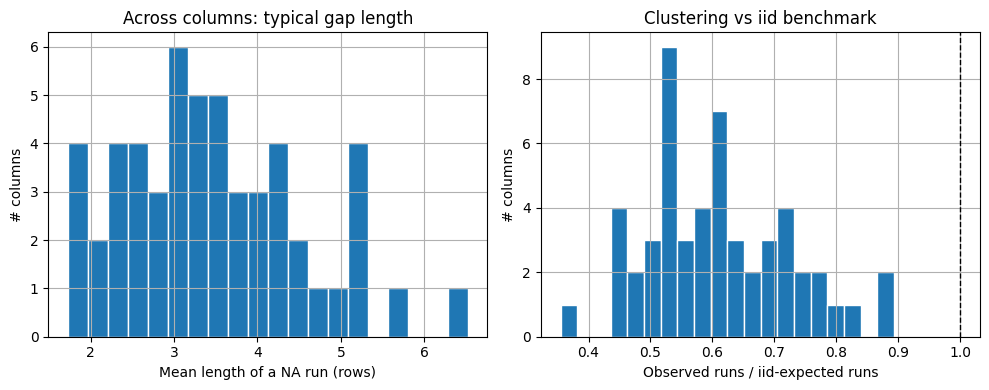

In [81]:

# Row order is treated as the time axis: contiguous NaNs = multi-day gaps in that series.
is_na = DF.isna()
n_rows, n_cols = is_na.shape

print("=== Whole dataset ===")
print(f"Share of (row, column) cells missing: {is_na.to_numpy().mean():.4f}")

na_per_row = is_na.sum(axis=1)
print(
    "NAs per row (how many series missing on the same day): "
    f"min={na_per_row.min()}, median={na_per_row.median():.0f}, max={na_per_row.max()}"
)

na_per_row.plot.hist(bins=30, figsize=(8, 4), edgecolor="white")
plt.xlabel("Number of columns NA on that row")
plt.ylabel("Count of rows")
plt.title("Co-missingness across columns on the same day")
plt.tight_layout()
plt.show()

# Do gaps tend to occur on the same calendar rows across columns?
miss_corr = is_na.astype(float).corr()
triu = np.triu_indices_from(miss_corr, k=1)
off_diag = miss_corr.to_numpy()[triu]
print(
    "\nPairwise correlation of missingness indicators (off-diagonal): "
    f"median={np.median(off_diag):.3f}, mean={off_diag.mean():.3f}"
)
print("(Higher values → missingness more aligned in time across series.)")

plt.figure(figsize=(7, 5.5))
plt.imshow(miss_corr, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="corr(indicator missing)")
plt.xlabel("Column (index in DF)")
plt.ylabel("Column (index in DF)")
plt.title("Missingness co-movement across columns")
plt.tight_layout()
plt.show()


def na_run_lengths(s: pd.Series) -> np.ndarray:
    """Lengths of each contiguous block of NaNs along the time axis."""
    mask = s.isna()
    if not mask.any():
        return np.array([], dtype=int)
    grp = (mask != mask.shift(fill_value=False)).cumsum()
    lengths = []
    for _, block in mask.groupby(grp):
        if bool(block.iloc[0]):
            lengths.append(int(block.sum()))
    return np.asarray(lengths, dtype=int)


rows = []
for col in DF.columns:
    lens = na_run_lengths(DF[col])
    n_na = int(DF[col].isna().sum())
    p = n_na / n_rows
    exp_runs = p + (n_rows - 1) * p * (1 - p) if n_rows else 0.0
    n_runs = len(lens)
    if n_runs == 0:
        rows.append(
            {
                "column": col,
                "n_na": n_na,
                "n_runs": 0,
                "mean_run": np.nan,
                "median_run": np.nan,
                "max_run": np.nan,
                "runs_vs_iid": np.nan,
            }
        )
    else:
        rows.append(
            {
                "column": col,
                "n_na": n_na,
                "n_runs": n_runs,
                "mean_run": float(lens.mean()),
                "median_run": float(np.median(lens)),
                "max_run": int(lens.max()),
                "runs_vs_iid": n_runs / exp_runs if exp_runs > 0 else np.nan,
            }
        )

run_summary = pd.DataFrame(rows).set_index("column").sort_values("mean_run", ascending=False)

print("\n=== Per-column contiguous NaN runs (time-ordered rows) ===")
print(
    "runs_vs_iid = (# observed NA runs) / (expected # runs if each row were NA "
    "independently with that column's marginal rate p).\n"
    "  < 1  → longer blocks / fewer runs than iid (gaps clump in time)\n"
    "  ~ 1  → similar fragmentation to iid at random\n"
    "  > 1  → shorter runs / more alternation than iid\n"
)
print("Largest mean contiguous NA length (rows ≈ days):")
print(run_summary.head(10).to_string())
print("\nSmallest mean contiguous NA length:")
print(run_summary.tail(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
run_summary["mean_run"].dropna().hist(ax=axes[0], bins=20, edgecolor="white")
axes[0].set_xlabel("Mean length of a NA run (rows)")
axes[0].set_ylabel("# columns")
axes[0].set_title("Across columns: typical gap length")

run_summary["runs_vs_iid"].dropna().hist(ax=axes[1], bins=20, edgecolor="white")
axes[1].axvline(1.0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("Observed runs / iid-expected runs")
axes[1].set_ylabel("# columns")
axes[1].set_title("Clustering vs iid benchmark")
plt.tight_layout()
plt.show()


## Understanding the distribution of prices

For each of the columns it would be great to see how different prices may evolve through time to see if there are any outliers when considering indexes vs farmers, and to potentially see how correlated prices from farmers are. Do they in general move together, or might there be quite a bit of variance. 


There might be several different views to get a perspective on this so let's plot a variety of different views to understand pricing dynamics in the market through time

### Average prices per index and farmer

count     53.000000
mean     162.467069
std        2.662272
min      156.835329
25%      160.016682
50%      162.699909
75%      164.269494
max      167.338368
dtype: float64

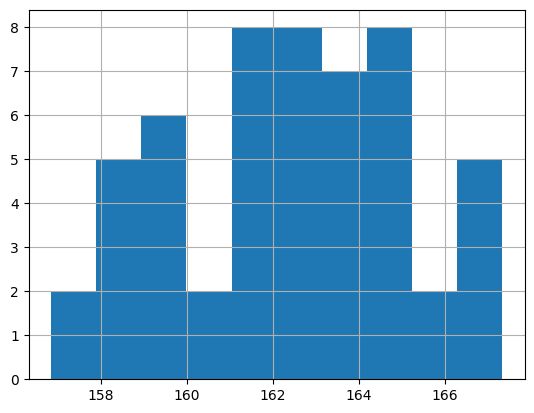

In [82]:
price_means = DF.mean()
price_means.hist()
price_means.describe()

### Average price over time 

<Axes: xlabel='time'>

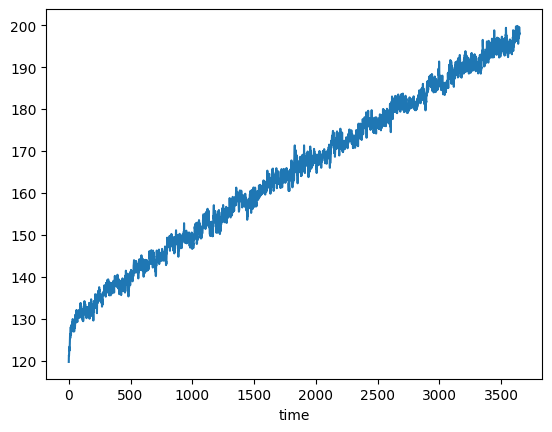

In [83]:
prices_over_time = DF.mean(axis=1)
prices_over_time.plot()

The time series of prices looks to be generally an increasing trend of prices, futhermore it looks like it's mean reverting to a general trend. It looks like the times series of the average price would be stationary once differenced with a linear model against time. This may inform our trading strategy, although we need to be careful not to overfit the data.

### Individual prices over this time

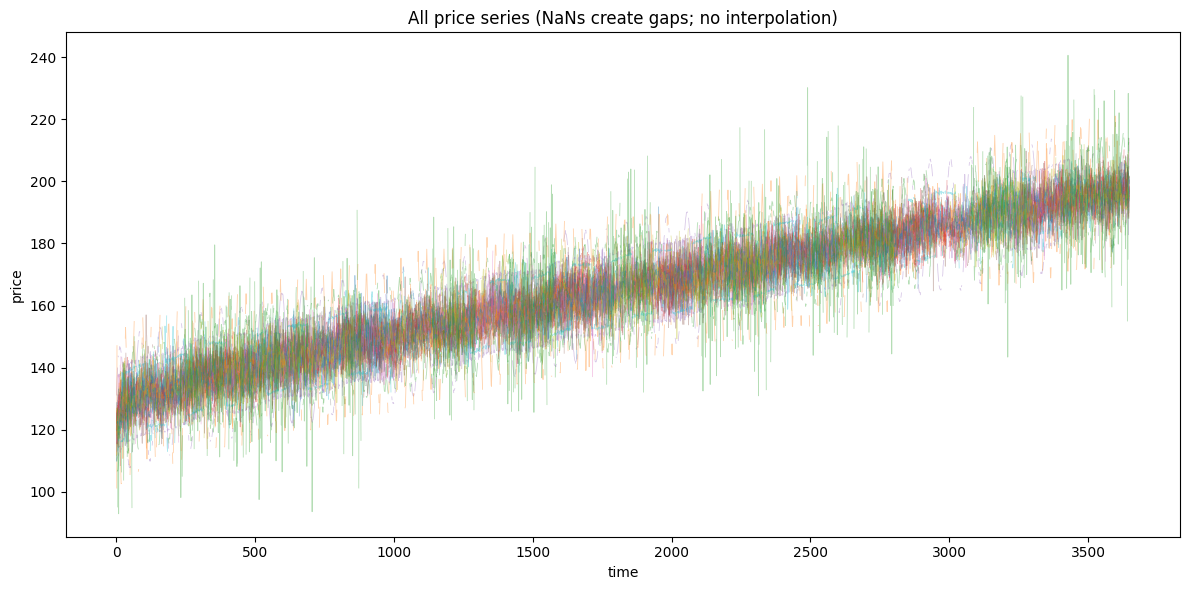

In [84]:
fig, ax = plt.subplots(figsize=(12, 6))

for col in DF.columns:
    ax.plot(DF.index, DF[col], linewidth=0.6, alpha=0.35)

ax.set_xlabel("time")
ax.set_ylabel("price")
ax.set_title("All price series (NaNs create gaps; no interpolation)")
plt.tight_layout()
plt.show()

# PCA analysis of time series data

/Users/nikhileshbelulkar/opt/miniconda3/envs/fingers_crossed/lib/python3.11/site-packages/sklearn/impute/_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



=== Mean impute (row avg per time) ===
  PCs for ≥80% variance: 1 (cumulative 0.9535)
  PCs for ≥90% variance: 1 (cumulative 0.9535)
  PCs for ≥95% variance: 1 (cumulative 0.9535)
  PC1–3 share: 0.9535, 0.0047, 0.0043 (total first 3: 0.9625)

=== Median impute (row per time) ===
  PCs for ≥80% variance: 1 (cumulative 0.9532)
  PCs for ≥90% variance: 1 (cumulative 0.9532)
  PCs for ≥95% variance: 1 (cumulative 0.9532)
  PC1–3 share: 0.9532, 0.0048, 0.0044 (total first 3: 0.9623)

=== ffill → bfill → mean ===
  PCs for ≥80% variance: 1 (cumulative 0.9141)
  PCs for ≥90% variance: 1 (cumulative 0.9141)
  PCs for ≥95% variance: 7 (cumulative 0.9525)
  PC1–3 share: 0.9141, 0.0085, 0.0079 (total first 3: 0.9304)

=== IterativeImputer ===
  PCs for ≥80% variance: 1 (cumulative 0.9388)
  PCs for ≥90% variance: 1 (cumulative 0.9388)
  PCs for ≥95% variance: 3 (cumulative 0.9512)
  PC1–3 share: 0.9388, 0.0065, 0.0059 (total first 3: 0.9512)


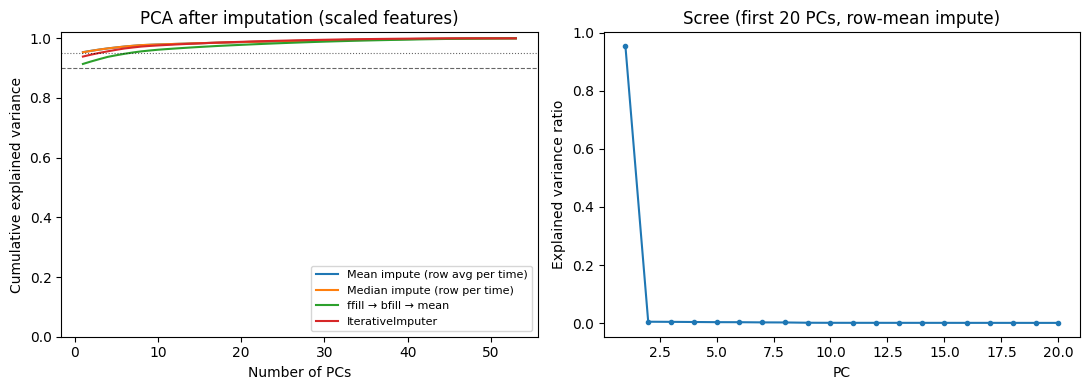

In [85]:

# Numeric price columns only (same panel as DF)
price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# Row-mean fill: each NA at time t is filled with the mean of *observed* prices that row (cross-section that day)
row_means = X_raw.mean(axis=1)
DF_filled_row_mean = X_raw.T.fillna(row_means).T
# If a whole row is NaN, row mean is NaN — fall back to 0 for PCA
DF_filled_row_mean = DF_filled_row_mean.fillna(0.0)

row_medians = X_raw.median(axis=1)
X_median = X_raw.T.fillna(row_medians).T.fillna(0.0)

# Time-ordered simple fill: carry last known, then next known, then column mean
X_ffill = X_raw.ffill().bfill().fillna(X_raw.mean()).fillna(0.0)

# Row/column structured imputation (slower; uses cross-sectional info)
_iter = IterativeImputer(max_iter=15, random_state=0)
X_iter = pd.DataFrame(
    _iter.fit_transform(X_raw),
    index=X_raw.index,
    columns=X_raw.columns,
)


def pca_report(X: pd.DataFrame, title: str) -> np.ndarray:
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("pca", PCA()),
        ]
    )
    pipe.fit(X)
    pca = pipe.named_steps["pca"]
    evr = pca.explained_variance_ratio_
    cum = np.cumsum(evr)
    print(f"\n=== {title} ===")
    for thr in (0.80, 0.90, 0.95):
        k = int(np.searchsorted(cum, thr) + 1)
        print(f"  PCs for ≥{thr:.0%} variance: {k} (cumulative {cum[k - 1]:.4f})")
    print(
        f"  PC1–3 share: {evr[0]:.4f}, {evr[1]:.4f}, {evr[2]:.4f} "
        f"(total first 3: {cum[2]:.4f})"
    )
    return cum


datasets = {
    "Mean impute (row avg per time)": DF_filled_row_mean,
    "Median impute (row per time)": X_median,
    "ffill → bfill → mean": X_ffill,
    "IterativeImputer": X_iter,
}

curves = {name: pca_report(data, name) for name, data in datasets.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(1, len(next(iter(curves.values()))) + 1)
for name, cum in curves.items():
    axes[0].plot(x, cum, label=name, linewidth=1.5)
axes[0].axhline(0.9, color="k", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].axhline(0.95, color="k", linestyle=":", linewidth=0.8, alpha=0.6)
axes[0].set_xlabel("Number of PCs")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("PCA after imputation (scaled features)")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_ylim(0, 1.02)

# Scree for the mean-imputed panel (primary baseline)
pipe_mean = Pipeline(
    [("scale", StandardScaler()), ("pca", PCA())]
)
pipe_mean.fit(DF_filled_row_mean)
evr_m = pipe_mean.named_steps["pca"].explained_variance_ratio_
axes[1].plot(np.arange(1, min(21, len(evr_m) + 1)), evr_m[:20], marker="o", ms=3)
axes[1].set_xlabel("PC")
axes[1].set_ylabel("Explained variance ratio")
axes[1].set_title("Scree (first 20 PCs, row-mean impute)")
plt.tight_layout()
plt.show()


### PCA on row-demeaned residuals

For each day (row), take the **cross-sectional mean** of observed prices, then form **residuals** = actual price minus that mean. This removes the common “level of the market” that day and focuses on **relative** cheapness/ richness across series.

**Missing values:** residuals are undefined where the price is missing. We set those to **0**, which is the same as imputing the missing level with the row mean before subtracting (so no deviation from the cross-sectional average).

PCA is then fit on this residual matrix (scaled) to see what explains **co-movement in relative prices**.

**Next:** PC **loadings** (which columns sit on the leading factors) — subsection immediately after the PCA code cell.


R_ij = price_ij − mean_t(prices on day t | observed). Missing cells → 0.
Shape (3650, 53). Row sums (exact 0 whenever that day has ≥1 price): min=-0.000000, max=0.000000

=== PCA on row-demeaned residuals (scaled) ===
  PCs for ≥80% variance: 37 (cumulative 0.8157)
  PCs for ≥90% variance: 43 (cumulative 0.9059)
  PCs for ≥95% variance: 47 (cumulative 0.9573)
  PC1–3 share: 0.0463, 0.0378, 0.0328 (sum first 3: 0.1169)


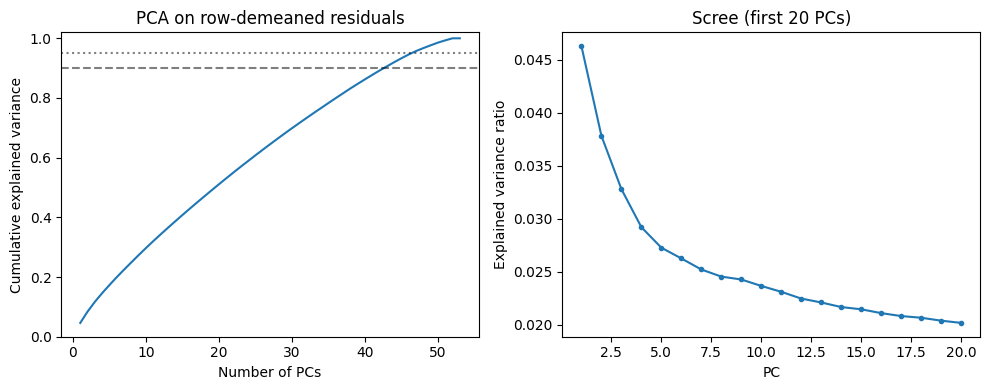

In [86]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# Cross-sectional mean each day (over non-missing prices in that row)
row_means = X_raw.mean(axis=1)
# Residual: column value minus row mean; NaN where price was missing
R = X_raw.sub(row_means, axis=0)
# Missing → 0 residual (equivalent to level imputed by row mean before demeaning)
R = R.fillna(0.0)

print("R_ij = price_ij − mean_t(prices on day t | observed). Missing cells → 0.")
print(f"Shape {R.shape}. Row sums (exact 0 whenever that day has ≥1 price): min={R.sum(axis=1).min():.6f}, max={R.sum(axis=1).max():.6f}")

pipe_res = Pipeline(
    [
        ("scale", StandardScaler()),
        ("pca", PCA()),
    ]
)
pipe_res.fit(R)
pca = pipe_res.named_steps["pca"]
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

print("\n=== PCA on row-demeaned residuals (scaled) ===")
for thr in (0.80, 0.90, 0.95):
    k = int(np.searchsorted(cum, thr) + 1)
    print(f"  PCs for ≥{thr:.0%} variance: {k} (cumulative {cum[k - 1]:.4f})")
print(f"  PC1–3 share: {evr[0]:.4f}, {evr[1]:.4f}, {evr[2]:.4f} (sum first 3: {cum[2]:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(np.arange(1, len(cum) + 1), cum)
ax[0].axhline(0.9, ls="--", color="k", alpha=0.5)
ax[0].axhline(0.95, ls=":", color="k", alpha=0.5)
ax[0].set_xlabel("Number of PCs")
ax[0].set_ylabel("Cumulative explained variance")
ax[0].set_title("PCA on row-demeaned residuals")
ax[0].set_ylim(0, 1.02)

m = min(20, len(evr))
ax[1].plot(np.arange(1, m + 1), evr[:m], marker="o", ms=3)
ax[1].set_xlabel("PC")
ax[1].set_ylabel("Explained variance ratio")
ax[1].set_title("Scree (first 20 PCs)")
plt.tight_layout()
plt.show()


#### PC loadings (which columns drive the factors?)

On **scaled** residual data, each PC is a direction in **column space**. **Large absolute loadings** on the **leading** PCs mean that column’s residual series **co-moves** with the main **shared** patterns (cross-sectional factors). **Small** loadings on those PCs mean the column’s residuals are **not** aligned with those directions — more **idiosyncratic** / “formless” in factor space.

This is **heuristic** for Problem 1 (indices vs farmers are unknown): **indices** in the PDF are *blends* of farmers, so we might expect them to sit **on** the shared cone; **nothing** here is a proof. We report:

- **|loading on PC1|** (rank columns).
- **Participation mass:** sum of squared loadings on the **first K PCs**, where **K** is the smaller of (i) the number of PCs needed for **≥75%** cumulative explained variance and (ii) **30** (cap). So you get at least 75% variance in the PC basis when that fits in 30 PCs; otherwise mass uses **30 PCs** and the printout shows actual cumulative variance.

Run after the PCA cell above (or this cell refits the same pipeline from `DF`).


Participation mass = sum of squared loadings on first 30 PCs. Rule: min(PCs for ≥75% var, 30) → K_75=34, K_use=30. Cumulative explained variance over those PCs: 0.6986.
       abs_loading_PC1  sq_loading_mass
count        53.000000        53.000000
mean          0.088405         0.698803
std           0.106137         0.069184
min           0.000159         0.558279
25%           0.026243         0.653449
50%           0.053640         0.690432
75%           0.108294         0.730879
max           0.486522         0.899526

Top 20 by |PC1 loading|:
        abs_loading_PC1  sq_loading_mass
col_11         0.486522         0.758358
col_42         0.444997         0.623660
col_28         0.362355         0.713175
col_50         0.310928         0.752677
col_26         0.249145         0.648028
col_31         0.204842         0.885171
col_24         0.147489         0.809821
col_12         0.147364         0.670237
col_51         0.146604         0.558279
col_52         0.145119         0.8

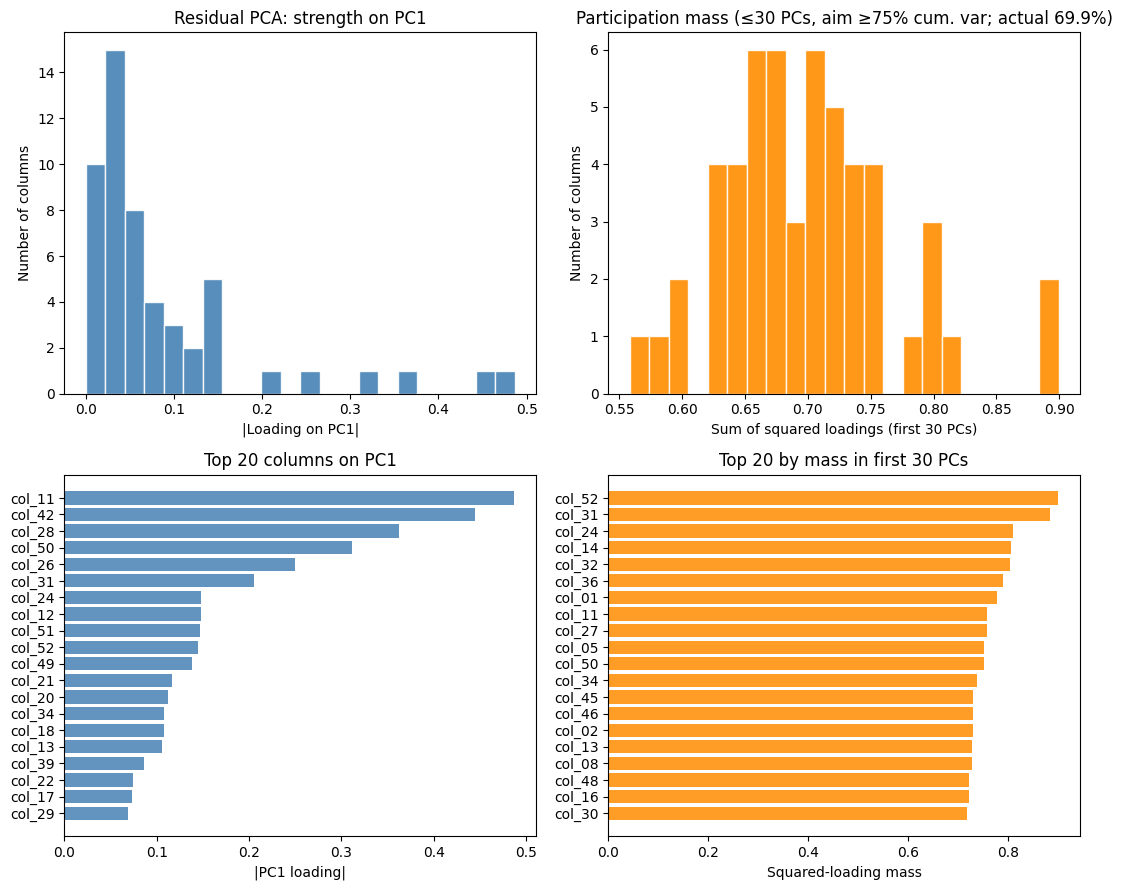

,abs_loading_PC1,sq_loading_mass
col_52,0.145119,0.899526
col_31,0.204842,0.885171
col_24,0.147489,0.809821
col_14,0.000159,0.805535
col_32,0.009692,0.805122
col_36,0.034046,0.791000
col_01,0.002192,0.777723
col_11,0.486522,0.758358
col_27,0.028203,0.758166
col_05,0.017038,0.753053


In [100]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
row_means = X_raw.mean(axis=1)
R = X_raw.sub(row_means, axis=0).fillna(0.0)

pipe_res = Pipeline(
    [
        ("scale", StandardScaler()),
        ("pca", PCA()),
    ]
)
pipe_res.fit(R)
pca = pipe_res.named_steps["pca"]
names = list(R.columns)

# Participation mass: PCs until 75% cumulative variance, capped at 30 PCs
TARGET_VAR = 0.75
MAX_PCS = 30
cum = np.cumsum(pca.explained_variance_ratio_)
K_75 = int(np.searchsorted(cum, TARGET_VAR) + 1)
K_75 = max(K_75, 1)
K_use = min(K_75, MAX_PCS, pca.n_components_)

# Loadings: variable j on PC k  ~  component[k,j] * sqrt(eigenvalue_k)
comp = pca.components_[:K_use]
ev = pca.explained_variance_[:K_use]
L = comp.T * np.sqrt(ev)
participation_mass = np.sum(L**2, axis=1)
pc1_abs = np.abs(pca.components_[0, :])

load_df = pd.DataFrame(
    {
        "abs_loading_PC1": pc1_abs,
        "sq_loading_mass": participation_mass,
    },
    index=names,
)

print(
    f"Participation mass = sum of squared loadings on first {K_use} PCs. "
    f"Rule: min(PCs for ≥{TARGET_VAR:.0%} var, {MAX_PCS}) → "
    f"K_75={K_75}, K_use={K_use}. "
    f"Cumulative explained variance over those PCs: {cum[K_use - 1]:.4f}."
)
print(load_df.describe())
print("\nTop 20 by |PC1 loading|:")
print(load_df.sort_values("abs_loading_PC1", ascending=False).head(20))
print("\nBottom 20 by |PC1 loading|:")
print(load_df.sort_values("abs_loading_PC1", ascending=True).head(20))
print(f"\nTop 20 by mass in first {K_use} PCs (squared loadings):")
print(load_df.sort_values("sq_loading_mass", ascending=False).head(20))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].hist(load_df["abs_loading_PC1"], bins=22, color="steelblue", edgecolor="white", alpha=0.9)
axes[0, 0].set_xlabel("|Loading on PC1|")
axes[0, 0].set_ylabel("Number of columns")
axes[0, 0].set_title("Residual PCA: strength on PC1")

axes[0, 1].hist(load_df.iloc[:, 1], bins=22, color="darkorange", edgecolor="white", alpha=0.9)
axes[0, 1].set_xlabel(f"Sum of squared loadings (first {K_use} PCs)")
axes[0, 1].set_ylabel("Number of columns")
axes[0, 1].set_title(
    f"Participation mass (≤{MAX_PCS} PCs, aim ≥{TARGET_VAR:.0%} cum. var; actual {cum[K_use - 1]:.1%})"
)

s1 = load_df.sort_values("abs_loading_PC1", ascending=False).reset_index()
axes[1, 0].barh(s1["index"][:20], s1["abs_loading_PC1"][:20], color="steelblue", alpha=0.85)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel("|PC1 loading|")
axes[1, 0].set_title("Top 20 columns on PC1")

col_mass = load_df.columns[1]
s2 = load_df.sort_values(col_mass, ascending=False).reset_index()
axes[1, 1].barh(s2["index"][:20], s2[col_mass][:20], color="darkorange", alpha=0.85)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel("Squared-loading mass")
axes[1, 1].set_title(f"Top 20 by mass in first {K_use} PCs")
plt.tight_layout()
plt.show()

load_df.sort_values(col_mass, ascending=False)


### How to read the residual PCA (exploratory)

In this notebook’s PCA on **row-demeaned residuals**, the output above reports how many PCs hit each variance threshold—often on the order of **~40–45 PCs** to reach **~90%** cumulative variance (use the exact number from your run). That is a statement about **how many orthogonal directions** you need to summarize **co-movement in relative prices** (after stripping out the common cross-sectional level each day)—not about “true” economic objects, but it is still useful intuition.

**Takeaway:** Relative-price “noise” is **high-dimensional**: there are many distinct patterns of who is cheap or rich versus the daily average, not just one or two factors. You can loosely think of each additional PC as capturing another **characterization of cross-sectional deviation** (another way the panel can wiggle away from the row mean).

**Relating to farmers vs indices (speculative):** The challenge mixes **many individual farmer series** with a **smaller set of index-like series**. A PC count in the forties is **broadly consistent** with a market where lots of idiosyncratic series each contribute their own variation, while a handful of indices might load on a subset of shared factors—but **PCs are not labels**: you cannot equate “43 PCs” to “43 farmers” (or “~10–12 indices”) without inspecting **loadings** and domain structure. Treat this as **supporting evidence for rich heterogeneity** in the residuals, not a headcount.


### Distribution of residual variance (per column)

**Residual** on day `t` for column `j`: take that day’s price minus the **average of all observed prices that day** (same day, across the row). That residual is how far that series sits above or below the **cross-sectional average** for that day.

**Residual variance** for a column = variance of those residuals **on days where that price is observed**. Missing days are **excluded** (we do not impute levels or zero out residuals for variance here).

We do **not** label columns as “index” vs “farmer” (that mapping isn’t given).

The plots show the **distribution of these per-column variances** (natural scale and log10 if helpful).


Per-column residual variance (missing days ignored).
count     53.000000
mean      39.252696
std       49.864833
min        4.905074
25%       13.058427
50%       25.583678
75%       30.371092
max      219.780406
dtype: float64


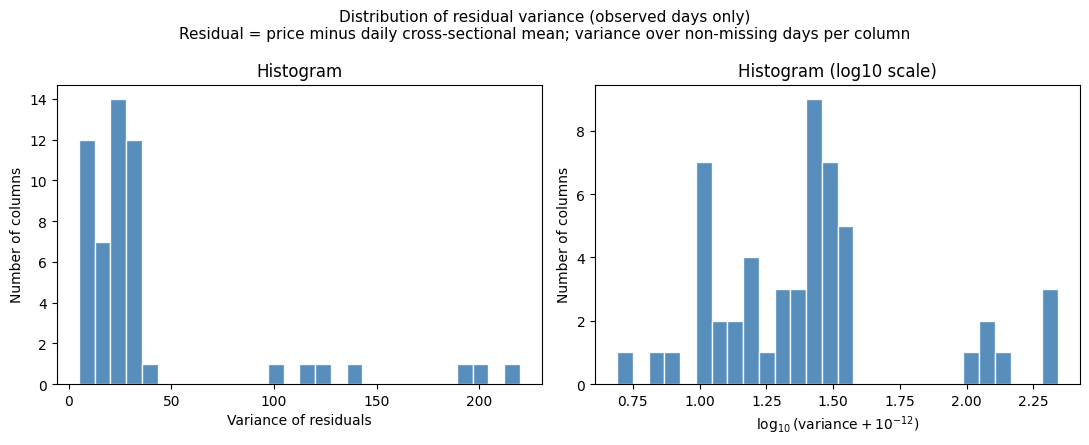

In [88]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# r_ij = price_ij minus cross-sectional mean on day i (mean over non-NaN in that row)
row_means = X_raw.mean(axis=1)
R = X_raw.sub(row_means, axis=0)

# Variance of residuals using only days where that column has a price (ignore missing days)
resid_var = R.apply(
    lambda s: s.dropna().var(ddof=1) if s.notna().sum() > 1 else np.nan
)

print("Per-column residual variance (missing days ignored).")
print(resid_var.describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(
    "Distribution of residual variance (observed days only)\n"
    "Residual = price minus daily cross-sectional mean; variance over non-missing days per column",
    fontsize=11,
)

v = resid_var.dropna()
axes[0].hist(v, bins=28, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].set_xlabel("Variance of residuals")
axes[0].set_ylabel("Number of columns")
axes[0].set_title("Histogram")

axes[1].hist(np.log10(v + 1e-12), bins=28, color="steelblue", edgecolor="white", alpha=0.9)
axes[1].set_xlabel(r"$\log_{10}(\mathrm{variance} + 10^{-12})$")
axes[1].set_ylabel("Number of columns")
axes[1].set_title("Histogram (log10 scale)")

plt.tight_layout()
plt.show()

residual_variance_by_col = pd.DataFrame({"residual_var_observed_only": resid_var})
# residual_variance_by_col.sort_values("residual_var_observed_only", ascending=False)


## Residual noise analysis

We study **row-mean residuals** $r_{t,j} = p_{t,j} - \bar{p}_t$ where $\bar{p}_t$ is the cross-sectional mean of **observed** prices that day.

The cells below are intentionally small: (1) build `R`, (2) **bias** (average residual per column vs 0), (3) **pooled** marginal distribution, (4) **shape** (skew/kurtosis per column), (5) **spectrum** (periodogram flatness ≈ white noise), (6) **short-lag autocorrelation** (near 0 ≈ no memory).

**Run this section top to bottom** — later code uses `R`, and the last table uses `flat_s` from the spectrum cell.


In [89]:
# Shared: residual matrix R (NaN where price missing — do not fill here)
price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
row_means = X_raw.mean(axis=1)
R = X_raw.sub(row_means, axis=0)
R.shape


(3650, 53)

### 1. Bias: is the average residual above or below zero?

For each column we take the **time average** of $r_{t,j}$ using **non-missing** days only. Values **systematically positive/negative** mean that series tends to sit **above/below** the daily cross-sectional average (after accounting for missingness in the mean).


count    53.000000
mean      0.001522
std       0.273615
min      -0.646581
25%      -0.134944
50%       0.000273
75%       0.081322
max       0.912109
dtype: float64


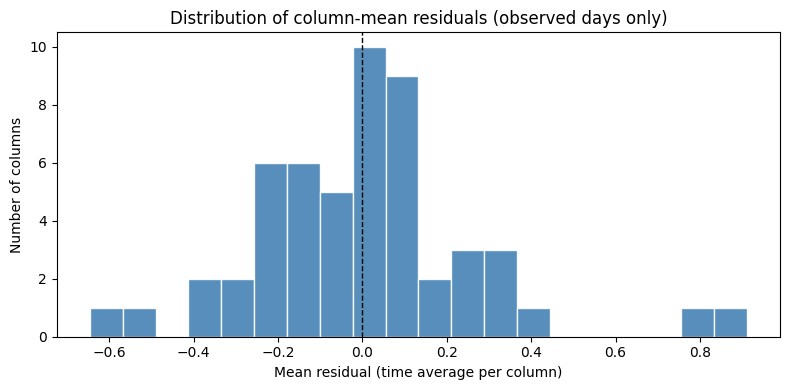

col_35   -0.646581
col_52   -0.518006
col_37   -0.405716
col_08   -0.381540
col_10   -0.313761
col_48   -0.257184
col_13   -0.252179
col_29   -0.231309
col_47   -0.223298
col_17   -0.212620
col_39   -0.207833
col_21   -0.187838
col_06   -0.143846
col_15   -0.134944
col_34   -0.132637
col_09   -0.121583
col_45   -0.115819
col_24   -0.107245
col_00   -0.099602
col_16   -0.078440
col_36   -0.070213
col_14   -0.057219
col_30   -0.040811
col_23   -0.021695
col_19   -0.020534
col_27   -0.007821
col_43    0.000273
col_32    0.002722
col_25    0.007112
col_18    0.022425
col_42    0.029783
col_03    0.030839
col_07    0.032974
col_02    0.056216
col_01    0.056972
col_46    0.062129
col_26    0.067715
col_50    0.067881
col_41    0.079151
col_28    0.081322
col_40    0.118026
col_44    0.128700
col_51    0.161786
col_11    0.192685
col_31    0.233057
col_05    0.253040
col_20    0.283455
col_38    0.304719
col_33    0.306564
col_12    0.349778
col_49    0.399247
col_04    0.830285
col_22    0.

In [90]:

col_mean_resid = R.mean(axis=0, skipna=True)
print(col_mean_resid.describe())
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(col_mean_resid.dropna(), bins=20, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(0.0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("Mean residual (time average per column)")
ax.set_ylabel("Number of columns")
ax.set_title("Distribution of column-mean residuals (observed days only)")
plt.tight_layout()
plt.show()
col_mean_resid.sort_values()


### 2. Pooled residuals: overall shape

All **observed** residual values (every column, every day) pooled into one sample. This is **not** i.i.d. (rows share the same day), but it shows whether mass is roughly centered and symmetric vs heavy-tailed.


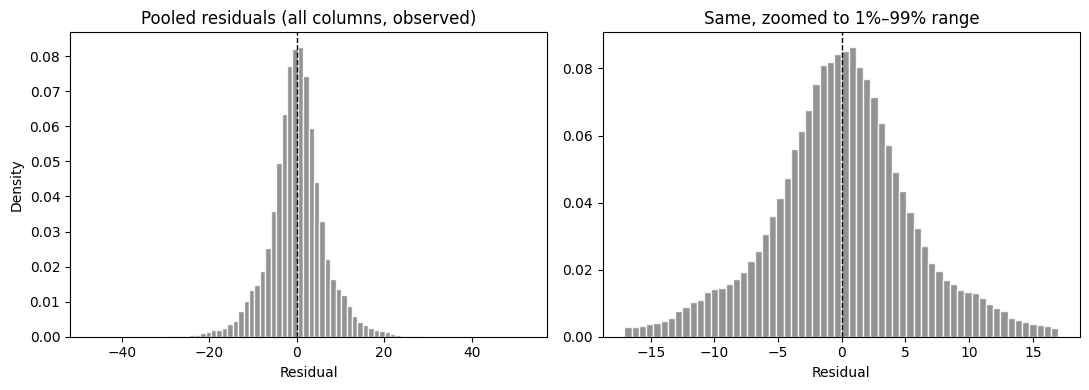

Pooled mean: 1.0035752117524956e-16 std: 6.285362567153125


In [91]:
pooled = R.stack().dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pooled, bins=80, density=True, color="gray", edgecolor="white", alpha=0.85)
axes[0].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Density")
axes[0].set_title("Pooled residuals (all columns, observed)")

# Zoom center (exclude extreme tails for readability)
q = pooled.quantile([0.01, 0.99])
m = pooled.between(q.iloc[0], q.iloc[1])
axes[1].hist(pooled[m], bins=60, density=True, color="gray", edgecolor="white", alpha=0.85)
axes[1].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual")
axes[1].set_title("Same, zoomed to 1%–99% range")
plt.tight_layout()
plt.show()

print("Pooled mean:", pooled.mean(), "std:", pooled.std())


### 3. Per-column shape: skewness and excess kurtosis

**Skew** $\neq 0$: asymmetry. **Excess kurtosis** $> 0$: heavier tails than Gaussian. Computed per column on **observed** residuals (pandas `skipna`).


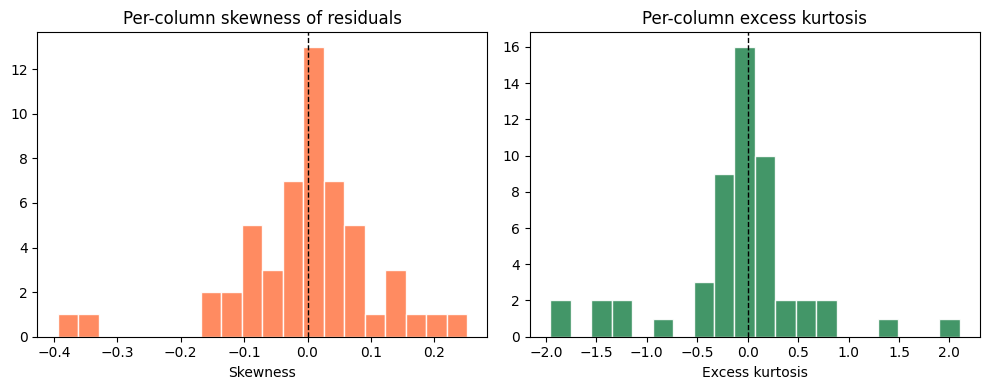

In [92]:
sk = R.skew(axis=0, skipna=True)
ku = R.kurtosis(axis=0, skipna=True)  # excess kurtosis (normal = 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(sk.dropna(), bins=20, color="coral", edgecolor="white", alpha=0.9)
axes[0].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[0].set_xlabel("Skewness")
axes[0].set_title("Per-column skewness of residuals")

axes[1].hist(ku.dropna(), bins=20, color="seagreen", edgecolor="white", alpha=0.9)
axes[1].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("Excess kurtosis")
axes[1].set_title("Per-column excess kurtosis")
plt.tight_layout()
plt.show()


### 4. Spectrum: periodogram “flatness” (white noise → flat PSD)

For **Gaussian white noise**, the **power spectral density** is **flat** across frequencies. A common scalar summary is **spectral flatness** (Wiener):

$$
\frac{\exp\bigl(\mathbb{E}[\log S(f)]\bigr)}{\mathbb{E}[S(f)]}
$$

in $(0,1]$, with values **closer to 1** when the spectrum is **more uniform** (more “noise-like”). We compute the **periodogram** per column on **observed-only** residual series (constant detrend), then flatness. Short series give noisy estimates — treat as exploratory.


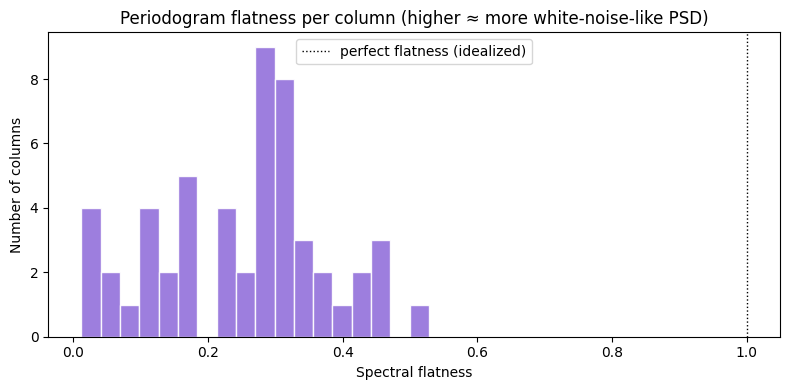

count    53.000000
mean      0.249453
std       0.126329
min       0.011953
25%       0.156269
50%       0.274675
75%       0.325082
max       0.528147
Name: spectral_flatness, dtype: float64

Columns closest to flat spectrum (top 10):
col_52    0.528147
col_14    0.458687
col_01    0.447107
col_33    0.443549
col_16    0.429146
col_27    0.428960
col_38    0.396508
col_41    0.371549
col_06    0.367782
col_47    0.346971
Name: spectral_flatness, dtype: float64


In [93]:


def periodogram_flatness(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 64:
        return np.nan
    _, pxx = periodogram(x, detrend="constant")
    pxx = np.maximum(pxx, 1e-20)
    return float(np.exp(np.mean(np.log(pxx))) / np.mean(pxx))


flatness = {}
for col in R.columns:
    flatness[col] = periodogram_flatness(R[col].dropna().to_numpy())

flat_s = pd.Series(flatness, name="spectral_flatness")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(flat_s.dropna(), bins=18, color="mediumpurple", edgecolor="white", alpha=0.9)
ax.axvline(1.0, color="k", linestyle=":", linewidth=1, label="perfect flatness (idealized)")
ax.set_xlabel("Spectral flatness")
ax.set_ylabel("Number of columns")
ax.set_title("Periodogram flatness per column (higher ≈ more white-noise-like PSD)")
ax.legend()
plt.tight_layout()
plt.show()

print(flat_s.describe())
print("\nColumns closest to flat spectrum (top 10):")
print(flat_s.sort_values(ascending=False).head(10))


### 5. Lag-1 autocorrelation (linear memory)

Under **i.i.d.** noise, **lag-1 correlation** in time should be **near zero**. We correlate **r_t** with **r_{t-1}** using only rows where **both** are observed (calendar-aligned), so missing days do not shift the lag.


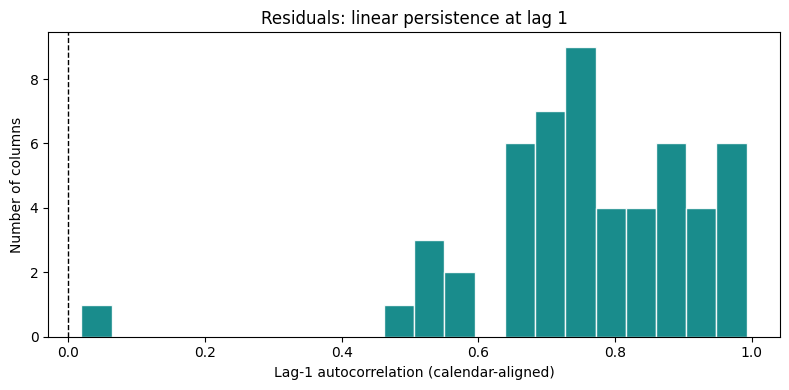

count    53.000000
mean      0.760020
std       0.165310
min       0.019144
25%       0.693868
50%       0.750764
75%       0.873349
max       0.992630
Name: lag1_acf, dtype: float64


,spectral_flatness,lag1_acf
col_52,0.528147,0.019144
col_14,0.458687,0.524470
col_01,0.447107,0.533664
col_33,0.443549,0.546348
col_16,0.429146,0.576673
col_27,0.428960,0.498376
col_38,0.396508,0.583716
col_41,0.371549,0.649092
col_06,0.367782,0.640041
col_47,0.346971,0.679312


In [94]:

acf1 = pd.Series({col: lag1_acf_calendar(R[col]) for col in R.columns}, name="lag1_acf")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(acf1.dropna(), bins=22, color="teal", edgecolor="white", alpha=0.9)
ax.axvline(0.0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("Lag-1 autocorrelation (calendar-aligned)")
ax.set_ylabel("Number of columns")
ax.set_title("Residuals: linear persistence at lag 1")
plt.tight_layout()
plt.show()

print(acf1.describe())
pd.DataFrame({"spectral_flatness": flat_s, "lag1_acf": acf1}).sort_values("spectral_flatness", ascending=False).head(12)


**Three code cells below:** (1) row-mean residuals, (2) **level prices** (imputed), (3) first differences and **comparison** across all three.

# Non-negative least squares (leave-one-out $R^2$)

**From the challenge PDF:** each *index* price is a **non-negative linear combination** of **farmer** flour prices (coefficients $c_{ij} \ge 0$); column labels are unknown. That motivates asking: which columns look like **blendable** from the others with **non-negative** weights?

**Setup:** For each column $j$, treat it as the response and **all other columns** as features (**no intercept**). Solve $\min_{\beta \ge 0} \| y - X\beta \|_2^2$ with **`scipy.optimize.nnls`**, then report

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}
$$

using the **same** rows (training fit). This is **exploratory**.

### Why can $R^2$ be negative?

Here $R^2$ is **not** the usual OLS $R^2$ with an intercept. NNLS forces **$\beta \ge 0$** and **no intercept**, so the fitted $\hat y$ can be a **worse** predictor than the **constant mean** $\bar y$. When $\mathrm{SS}_\mathrm{res} > \mathrm{SS}_\mathrm{tot}$, the formula above gives **$R^2 < 0$**. That means “constrained cone fit is worse than predicting the column mean.” It is **not** a bug.

**Three panels:**

1. **Row-mean residuals** — subtract cross-sectional daily mean; **missing → 0** (complete matrix).
2. **Level prices** — **row-mean imputation** for missing cells (same as elsewhere), then NNLS on **levels** (not differences).
3. **First differences** — $\Delta p_t$; **NaN → 0** for missing diffs.

Run cells **in order** for the combined comparison table and scatter plots.


NNLS on row-mean residuals — leave-one-out R^2
(higher = easier to match others; R^2 can be negative — see markdown.)

count    53.000000
mean      0.068227
std       0.106265
min      -0.000518
25%       0.010612
50%       0.020133
75%       0.046788
max       0.450150
Name: r2_nnls, dtype: float64

Top 15 columns by R^2:
col_11    0.450150
col_50    0.372273
col_42    0.321446
col_28    0.269364
col_46    0.261979
col_30    0.245842
col_48    0.209929
col_34    0.199581
col_32    0.195854
col_05    0.166018
col_26    0.119568
col_19    0.053881
col_51    0.053556
col_17    0.046788
col_20    0.046783
Name: r2_nnls, dtype: float64

Bottom 15 columns by R^2:
col_52   -0.000518
col_31   -0.000126
col_14    0.002631
col_36    0.003254
col_12    0.003788
col_38    0.003796
col_01    0.005209
col_24    0.005515
col_33    0.007600
col_49    0.008746
col_02    0.009676
col_25    0.009747
col_08    0.010525
col_41    0.010612
col_03    0.011457
Name: r2_nnls, dtype: float64


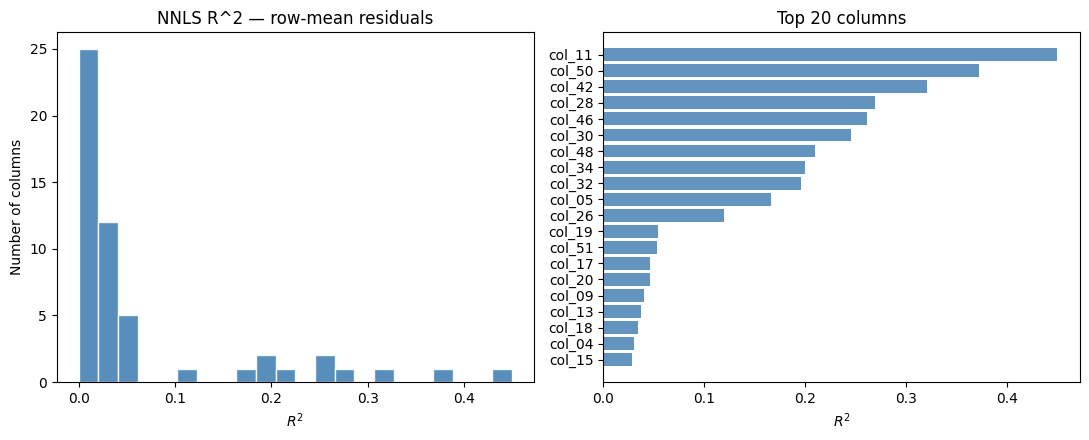

col_00    0.020133
col_01    0.005209
col_02    0.009676
col_03    0.011457
col_04    0.030079
col_05    0.166018
col_06    0.012940
col_07    0.023999
col_08    0.010525
col_09    0.040561
col_10    0.015538
col_11    0.450150
col_12    0.003788
col_13    0.037279
col_14    0.002631
col_15    0.028997
col_16    0.014873
col_17    0.046788
col_18    0.034382
col_19    0.053881
col_20    0.046783
col_21    0.026106
col_22    0.014853
col_23    0.024227
col_24    0.005515
col_25    0.009747
col_26    0.119568
col_27    0.019726
col_28    0.269364
col_29    0.014371
col_30    0.245842
col_31   -0.000126
col_32    0.195854
col_33    0.007600
col_34    0.199581
col_35    0.020087
col_36    0.003254
col_37    0.012300
col_38    0.003796
col_39    0.015325
col_40    0.023179
col_41    0.010612
col_42    0.321446
col_43    0.022745
col_44    0.020647
col_45    0.018861
col_46    0.261979
col_47    0.019878
col_48    0.209929
col_49    0.008746
col_50    0.372273
col_51    0.053556
col_52   -0.

In [95]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()

# Row-mean residuals; missing -> 0 (same as PCA on R)
row_means = X_raw.mean(axis=1)
R = X_raw.sub(row_means, axis=0).fillna(0.0)
Z_resid = R.to_numpy(dtype=np.float64)
names = list(price_cols)




r2_resid = nnls_leave_one_out_r2(Z_resid, names)

print("NNLS on row-mean residuals — leave-one-out R^2")
print("(higher = easier to match others; R^2 can be negative — see markdown.)\n")
print(r2_resid.describe())
print("\nTop 15 columns by R^2:")
print(r2_resid.sort_values(ascending=False).head(15))
print("\nBottom 15 columns by R^2:")
print(r2_resid.sort_values(ascending=True).head(15))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(r2_resid.dropna(), bins=22, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].set_xlabel(r"$R^2$")
axes[0].set_ylabel("Number of columns")
axes[0].set_title("NNLS R^2 — row-mean residuals")

sorted_r = r2_resid.sort_values(ascending=False).rename_axis("column").reset_index()
axes[1].barh(sorted_r["column"][:20], sorted_r["r2_nnls"][:20], color="steelblue", alpha=0.85)
axes[1].set_xlabel(r"$R^2$")
axes[1].set_title("Top 20 columns")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

r2_resid


NNLS on level prices (row-mean imputed missing) — leave-one-out R^2
(R^2 can be negative — see markdown above.)

count    53.000000
mean      0.955154
std       0.052378
min       0.759226
25%       0.960473
50%       0.969201
75%       0.983545
max       0.995197
Name: r2_nnls, dtype: float64

Top 15 columns by R^2:
col_30    0.995197
col_11    0.992808
col_42    0.992733
col_46    0.991599
col_48    0.991474
col_50    0.989382
col_51    0.989315
col_26    0.987376
col_17    0.986858
col_20    0.985578
col_13    0.985226
col_18    0.984809
col_44    0.984256
col_47    0.983545
col_15    0.983323
Name: r2_nnls, dtype: float64

Bottom 15 columns by R^2:
col_31    0.759226
col_24    0.781550
col_52    0.799008
col_34    0.862394
col_32    0.870974
col_12    0.875387
col_49    0.887896
col_45    0.939704
col_36    0.952349
col_38    0.953636
col_14    0.956369
col_02    0.957563
col_39    0.957918
col_08    0.960473
col_23    0.960790
Name: r2_nnls, dtype: float64


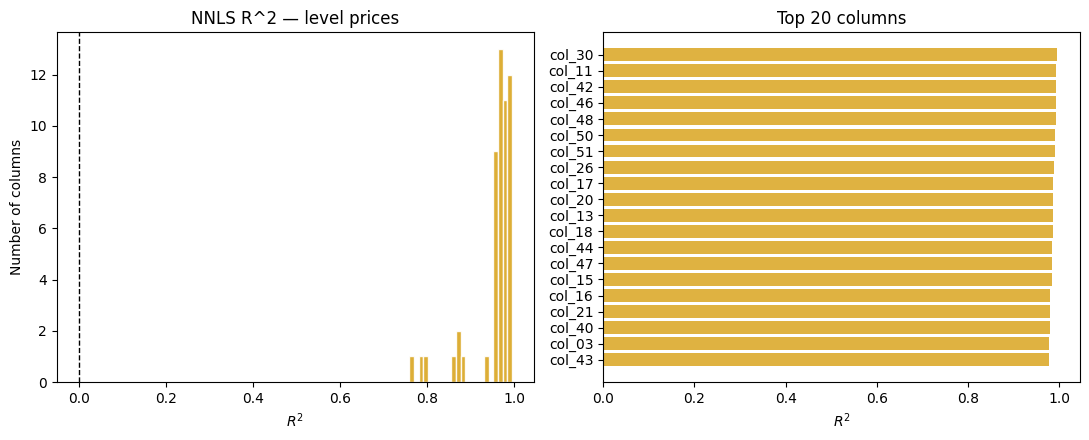

col_00    0.966441
col_01    0.965517
col_02    0.957563
col_03    0.978043
col_04    0.966889
col_05    0.974954
col_06    0.969201
col_07    0.962115
col_08    0.960473
col_09    0.965862
col_10    0.968482
col_11    0.992808
col_12    0.875387
col_13    0.985226
col_14    0.956369
col_15    0.983323
col_16    0.980190
col_17    0.986858
col_18    0.984809
col_19    0.967120
col_20    0.985578
col_21    0.979180
col_22    0.977095
col_23    0.960790
col_24    0.781550
col_25    0.968548
col_26    0.987376
col_27    0.969754
col_28    0.975402
col_29    0.964609
col_30    0.995197
col_31    0.759226
col_32    0.870974
col_33    0.967901
col_34    0.862394
col_35    0.971230
col_36    0.952349
col_37    0.960988
col_38    0.953636
col_39    0.957918
col_40    0.978346
col_41    0.969202
col_42    0.992733
col_43    0.977375
col_44    0.984256
col_45    0.939704
col_46    0.991599
col_47    0.983545
col_48    0.991474
col_49    0.887896
col_50    0.989382
col_51    0.989315
col_52    0.

In [96]:

price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
names = list(price_cols)

# Level prices: fill missing with row (day) mean so NNLS has a full matrix
row_means = X_raw.mean(axis=1)
X_level = X_raw.T.fillna(row_means).T.fillna(0.0)
Z_level = X_level.to_numpy(dtype=np.float64)




r2_level = nnls_leave_one_out_r2(Z_level, names)

print("NNLS on level prices (row-mean imputed missing) — leave-one-out R^2")
print("(R^2 can be negative — see markdown above.)\n")
print(r2_level.describe())
print("\nTop 15 columns by R^2:")
print(r2_level.sort_values(ascending=False).head(15))
print("\nBottom 15 columns by R^2:")
print(r2_level.sort_values(ascending=True).head(15))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(r2_level.dropna(), bins=22, color="goldenrod", edgecolor="white", alpha=0.9)
axes[0].set_xlabel(r"$R^2$")
axes[0].set_ylabel("Number of columns")
axes[0].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[0].set_title("NNLS R^2 — level prices")

sorted_l = r2_level.sort_values(ascending=False).rename_axis("column").reset_index()
axes[1].barh(sorted_l["column"][:20], sorted_l["r2_nnls"][:20], color="goldenrod", alpha=0.85)
axes[1].set_xlabel(r"$R^2$")
axes[1].set_title("Top 20 columns")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

r2_level


NNLS on first differences — leave-one-out R^2

count    53.000000
mean      0.042007
std       0.073542
min       0.002890
25%       0.005070
50%       0.008569
75%       0.023494
max       0.302381
Name: r2_nnls, dtype: float64

Top 15 columns by R^2:
col_11    0.302381
col_50    0.223546
col_34    0.210587
col_46    0.205895
col_28    0.191006
col_42    0.184695
col_30    0.183661
col_48    0.136897
col_05    0.118906
col_26    0.053404
col_20    0.037545
col_45    0.029230
col_19    0.028261
col_32    0.023494
col_09    0.023138
Name: r2_nnls, dtype: float64

Bottom 15 columns by R^2:
col_24    0.002890
col_52    0.003626
col_37    0.003657
col_49    0.003685
col_21    0.003699
col_35    0.004058
col_14    0.004114
col_08    0.004157
col_31    0.004160
col_06    0.004414
col_41    0.004547
col_51    0.004615
col_12    0.004685
col_23    0.005070
col_47    0.005993
Name: r2_nnls, dtype: float64


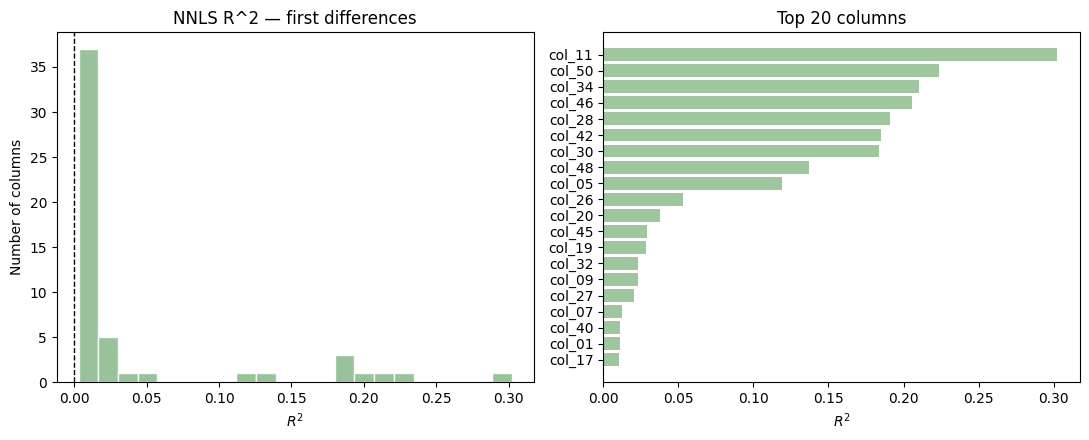


Combined summary (describe):
       r2_residuals_rowmean  r2_level_prices  r2_first_diff
count             53.000000        53.000000      53.000000
mean               0.068227         0.955154       0.042007
std                0.106265         0.052378       0.073542
min               -0.000518         0.759226       0.002890
25%                0.010612         0.960473       0.005070
50%                0.020133         0.969201       0.008569
75%                0.046788         0.983545       0.023494
max                0.450150         0.995197       0.302381


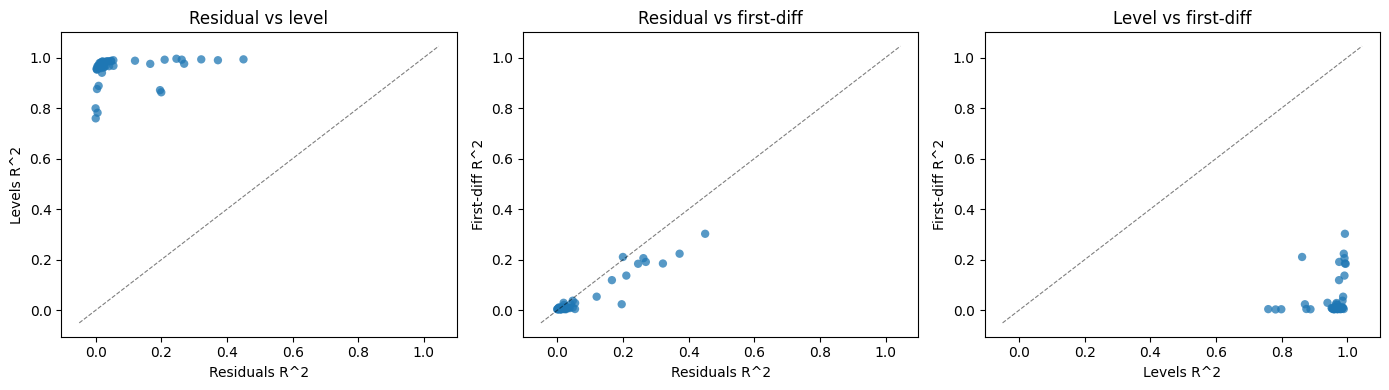

In [97]:

# Run the **residuals** and **levels** NNLS cells above first for the full comparison.
price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
names = list(price_cols)

D = X_raw.diff().fillna(0.0)
Z_diff = D.to_numpy(dtype=np.float64)




r2_diff = nnls_leave_one_out_r2(Z_diff, names)

print("NNLS on first differences — leave-one-out R^2\n")
print(r2_diff.describe())
print("\nTop 15 columns by R^2:")
print(r2_diff.sort_values(ascending=False).head(15))
print("\nBottom 15 columns by R^2:")
print(r2_diff.sort_values(ascending=True).head(15))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(r2_diff.dropna(), bins=22, color="darkseagreen", edgecolor="white", alpha=0.9)
axes[0].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[0].set_xlabel(r"$R^2$")
axes[0].set_ylabel("Number of columns")
axes[0].set_title("NNLS R^2 — first differences")

sorted_d = r2_diff.sort_values(ascending=False).rename_axis("column").reset_index()
axes[1].barh(sorted_d["column"][:20], sorted_d["r2_nnls"][:20], color="darkseagreen", alpha=0.85)
axes[1].set_xlabel(r"$R^2$")
axes[1].set_title("Top 20 columns")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

have_r = "r2_resid" in globals()
have_l = "r2_level" in globals()
if not have_r or not have_l:
    print("Run the residuals NNLS cell and the level-prices NNLS cell above for the 3-way summary and scatters.")
if have_r and have_l:
    summary = pd.DataFrame(
        {
            "r2_residuals_rowmean": r2_resid,
            "r2_level_prices": r2_level,
            "r2_first_diff": r2_diff,
        }
    )
    print("\nCombined summary (describe):")
    print(summary.describe())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    lo = summary.min().min()
    hi = summary.max().max()
    pad = 0.05 * (hi - lo) if hi > lo else 0.05

    axes[0].scatter(summary["r2_residuals_rowmean"], summary["r2_level_prices"], alpha=0.75, edgecolors="none")
    axes[0].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, alpha=0.5)
    axes[0].set_xlabel("Residuals R^2")
    axes[0].set_ylabel("Levels R^2")
    axes[0].set_title("Residual vs level")

    axes[1].scatter(summary["r2_residuals_rowmean"], summary["r2_first_diff"], alpha=0.75, edgecolors="none")
    axes[1].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, alpha=0.5)
    axes[1].set_xlabel("Residuals R^2")
    axes[1].set_ylabel("First-diff R^2")
    axes[1].set_title("Residual vs first-diff")

    axes[2].scatter(summary["r2_level_prices"], summary["r2_first_diff"], alpha=0.75, edgecolors="none")
    axes[2].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, alpha=0.5)
    axes[2].set_xlabel("Levels R^2")
    axes[2].set_ylabel("First-diff R^2")
    axes[2].set_title("Level vs first-diff")

    plt.tight_layout()
    plt.show()

    summary.sort_values("r2_residuals_rowmean", ascending=False)


## First-pass index prediction table (feature fusion)

This section builds one per-column table of signals, then creates a simple heuristic score and boolean prediction.

- Signals used: PCA loading strength, PCA participation mass, NNLS R^2 (residuals / levels / differences), residual variance, residual-noise diagnostics.
- Thresholding: percentile-based cutoffs (transparent, tunable).
- Output: `index_feature_table` with flags and `predict_index_first_pass`.


In [ ]:
# Build feature table from DF (self-contained)
price_cols = DF.select_dtypes(include=[np.number]).columns
X_raw = DF[price_cols].copy()
col_names = list(price_cols)

# Core transforms
row_means = X_raw.mean(axis=1)
R_obs = X_raw.sub(row_means, axis=0)
R0 = R_obs.fillna(0.0)
X_level = X_raw.T.fillna(row_means).T.fillna(0.0)
D = X_raw.diff().fillna(0.0)

# PCA on row-demeaned residuals (scaled)
pipe = Pipeline([("scale", StandardScaler()), ("pca", PCA())])
pipe.fit(R0)
pca = pipe.named_steps["pca"]

TARGET_VAR = 0.75
MAX_PCS = 30
cum = np.cumsum(pca.explained_variance_ratio_)
K_75 = int(np.searchsorted(cum, TARGET_VAR) + 1)
K_use = min(max(K_75, 1), MAX_PCS, pca.n_components_)

comp = pca.components_[:K_use]
ev = pca.explained_variance_[:K_use]
L = comp.T * np.sqrt(ev)
pca_mass = np.sum(L**2, axis=1)
pc1_abs = np.abs(pca.components_[0, :])

# NNLS explainability
r2_resid = nnls_leave_one_out_r2(R0.to_numpy(dtype=np.float64), col_names)
r2_level = nnls_leave_one_out_r2(X_level.to_numpy(dtype=np.float64), col_names)
r2_diff = nnls_leave_one_out_r2(D.to_numpy(dtype=np.float64), col_names)

# Residual diagnostics on observed data
resid_var_obs = R_obs.apply(lambda s: s.dropna().var(ddof=1) if s.notna().sum() > 1 else np.nan)
mean_resid = R_obs.mean(axis=0, skipna=True)
flat_s = pd.Series({c: periodogram_flatness(R_obs[c].dropna().to_numpy()) for c in col_names}, name="spectral_flatness")
acf1 = pd.Series({c: lag1_acf_calendar(R_obs[c]) for c in col_names}, name="lag1_acf")

index_feature_table = pd.DataFrame(
    {
        "abs_loading_PC1": pc1_abs,
        "sq_loading_mass": pca_mass,
        "r2_nnls_residual": r2_resid,
        "r2_nnls_level": r2_level,
        "r2_nnls_diff": r2_diff,
        "residual_var_observed": resid_var_obs,
        "mean_residual": mean_resid,
        "spectral_flatness": flat_s,
        "lag1_acf": acf1,
    },
    index=col_names,
)

# Heuristic flags (tunable cutoffs)
q_hi = 0.75
q_lo = 0.40
index_feature_table["flag_high_pc1_loading"] = index_feature_table["abs_loading_PC1"] >= index_feature_table["abs_loading_PC1"].quantile(q_hi)
index_feature_table["flag_high_pc_mass"] = index_feature_table["sq_loading_mass"] >= index_feature_table["sq_loading_mass"].quantile(q_hi)
index_feature_table["flag_high_r2_resid"] = index_feature_table["r2_nnls_residual"] >= index_feature_table["r2_nnls_residual"].quantile(q_hi)
index_feature_table["flag_high_r2_level"] = index_feature_table["r2_nnls_level"] >= index_feature_table["r2_nnls_level"].quantile(q_hi)
index_feature_table["flag_high_r2_diff"] = index_feature_table["r2_nnls_diff"] >= index_feature_table["r2_nnls_diff"].quantile(q_hi)
index_feature_table["flag_low_residual_var"] = index_feature_table["residual_var_observed"] <= index_feature_table["residual_var_observed"].quantile(q_lo)
index_feature_table["flag_flat_spectrum"] = index_feature_table["spectral_flatness"] >= index_feature_table["spectral_flatness"].quantile(q_hi)
index_feature_table["flag_low_abs_lag1"] = index_feature_table["lag1_acf"].abs() <= index_feature_table["lag1_acf"].abs().quantile(q_lo)

flag_cols = [c for c in index_feature_table.columns if c.startswith("flag_")]
index_feature_table["index_score"] = index_feature_table[flag_cols].sum(axis=1)
index_feature_table["predict_index_first_pass"] = index_feature_table["index_score"] >= 4

print(f"Using K_use={K_use} PCs for mass (K_75={K_75}, cum_var={cum[K_use-1]:.4f}).")
print("Predicted index count:", int(index_feature_table["predict_index_first_pass"].sum()))

index_feature_table.sort_values(
    ["predict_index_first_pass", "index_score", "r2_nnls_residual", "sq_loading_mass"],
    ascending=[False, False, False, False],
)
